# MScFE 610 Financial Econometrics - GWP1

This executed notebook contains the code and numerical outputs for the revised PDF. The report contains the proofs, explanations, plots, and result tables. No code is needed in the PDF.

## Reproduction

Run the cells in order using Python with NumPy, pandas, SciPy, statsmodels 0.14.6, Matplotlib, and IPython. Exact installed versions are printed below. Both supplied datasets are embedded verbatim for portability. If the original CSVs are available beside the notebook or in an `upload` subdirectory, those files are read first. The Problem 5 CSV has an extra layer of whole-row quoting; the loader removes that layer without changing numeric observations.

The model-selection dataset is the file assigned to **odd-numbered groups**. 
Problem 1e reproduces the draft's seed 123 and design `Z = 0.6X + v`, then adds 1,000 Monte Carlo repetitions at each sample size using seed 20260923. Problem 2b reproduces the draft's seed 42. For Problem 5, ADF lag selection uses AIC over 0-16 lags; system lag selection uses 0-10 difference lags and an unrestricted constant. Both selected-model Johansen tests determine the VECM rank. Alternative-lag sensitivity is reported explicitly.


In [1]:
EMBEDDED_CSV = {'FE-GWP1_model_selection_1.csv': 'Y,X1,X2,X3,X4,X5\n3.388409671,0.017953925,-0.800583411,-0.352453955,2.18720988,1.014886598\n0.287191037,0.083056858,-0.597947149,-0.357638635,-1.630284034,0.221841274\n3.989644613,-0.923436993,-1.386574993,1.180202111,0.632606238,-1.576638005\n-2.959602175,-0.313774803,2.955132661,-1.798692283,-2.117620643,0.159290963\n0.529772671,0.388995555,1.019610639,0.472062377,0.59049654,0.877048181\n-0.618180162,-0.30023871,-0.840477534,-0.54547103,-2.697316306,0.687755275\n2.349344682,-0.784111372,-1.270972032,-1.892353434,1.297552855,0.986759919\n-1.238875829,0.195307192,-0.593705128,-0.034412901,-0.947754112,2.237073728\n0.303064084,0.657370332,0.127576393,0.473624131,-0.487248014,0.458567427\n0.565263762,-0.400191449,-0.010746058,-1.262076037,1.296342711,-0.426830174\n0.816953898,-0.168541012,-0.712706346,-1.099678723,0.699949386,-3.526357032\n3.074031902,0.363607402,-0.398022297,-0.999255919,0.914173226,-1.105005964\n0.585286083,0.787225507,1.147054496,-1.491945198,1.068073605,0.28768958\n2.199919169,-0.33311698,-0.777934634,0.324878323,0.572281998,0.228637399\n0.659344949,0.479205991,1.814061015,0.567670773,0.013198917,0.536354778\n1.042188673,0.53605967,1.288724309,1.384952468,0.415519414,-0.634161006\n-0.220075349,0.65200559,0.493269922,-0.882693866,-0.298924093,1.436763249\n1.093721359,-0.163314482,0.729408271,0.756445898,0.352389974,-0.371332638\n0.723301118,-0.079010835,1.35342672,0.771416096,0.589380487,-2.809265304\n0.728755404,-0.595712301,-0.916810455,-0.299550072,-1.565714452,0.000765175\n0.875274034,-0.670920381,0.368038702,-0.450687467,-0.032975956,-1.30857679\n1.507346242,-0.096773601,0.420291977,0.249373649,0.714019873,-1.695062811\n0.105394982,1.049411049,0.392881153,-0.917066958,0.284831133,0.50513155\n0.353903842,0.048662076,-1.042976965,-0.214029686,0.07062897,0.081254683\n2.254350769,0.459294167,-1.121871274,1.104877942,1.059465754,-0.045649498\n2.437699026,0.716028116,-0.405055916,0.210393016,1.554623407,-0.563962514\n1.801424086,-0.035216263,0.977226037,-0.380577519,1.129798256,2.499820451\n2.726703357,0.174174756,-0.750218916,-0.422337233,0.745710844,0.994092793\n1.095413283,0.013805748,-0.282930234,0.816000765,-1.283212901,0.107567267\n2.137298741,0.154707993,0.049330605,-0.655158339,0.498441976,-0.781240618\n0.466429022,-0.130861778,1.441332076,0.2792668,0.657466149,0.809332909\n0.664513653,-0.725517709,-0.900467377,-0.012525314,0.036792676,-0.956201079\n1.826812187,-0.429403886,-0.176501003,0.599905189,-0.389931076,-0.779418758\n-0.049204273,-0.723541416,1.620789377,0.92362861,0.432558194,1.505460399\n0.96422136,0.074911114,-0.386414233,1.59554792,-1.133785248,-0.63366301\n2.133599908,-0.653251269,-0.671299245,0.472062792,0.327892366,-0.548405693\n2.065194622,-0.08987704,0.423164159,-1.025787169,1.883843747,-1.55395178\n1.647541318,-0.635852822,0.515817445,0.943173592,0.319990172,-0.872643768\n2.215763937,0.29780321,0.812861246,-0.070490364,0.967999779,-1.998749026\n-1.145076527,0.350591191,0.360802839,-1.357353005,-1.03463507,1.529265207\n0.336166528,-0.173746585,-0.096523662,-0.444471925,0.023180591,0.510973701\n2.935884423,-0.15943482,-0.850134962,0.437706624,0.249230634,-0.374598983\n5.176803003,0.162439718,0.599166657,1.278625733,1.921792389,-0.012898771\n-0.198970974,0.621769453,0.086935771,-2.213984311,1.381516203,-0.123342764\n2.572383031,-0.186234815,-1.198789262,0.659145513,1.442322071,1.231884473\n1.813816936,0.160449995,0.050434794,-1.886425834,0.867743603,-0.185783825\n1.866706817,-0.100560741,-0.831180798,0.122183817,-0.200474341,0.227508372\n1.348322066,1.083061536,0.037869868,0.760455987,-0.367184145,-0.539681496\n2.364131233,-0.451415974,-0.7289137,-1.06897744,0.102918911,0.022933233\n0.688422571,0.789729589,0.10682172,0.140430307,-0.911139631,-0.150628111\n3.832122928,0.11798791,-1.352547462,0.615924617,1.026757512,-1.0842788\n-0.737578554,-0.046128815,1.257355136,-0.493999993,0.565890109,0.133920704\n1.327305204,-0.746283261,1.196758637,1.132914044,0.570051694,-0.98993612\n-0.423155479,-0.434290405,0.818352245,-0.398437249,-0.596686654,1.382723626\n1.304923848,0.40309444,2.626888076,0.419614502,0.357154513,-1.19863996\n1.565593325,-0.466789922,-0.201522805,1.658633025,-0.059198055,-1.136466958\n1.000834685,0.032177841,0.804437551,0.488249087,1.095984426,-1.691047785\n1.857873439,-0.383015492,-0.638357654,-0.357407853,-0.239389814,-0.972252577\n2.352451637,0.437250595,-0.521614964,1.617775034,0.280175603,-1.007398921\n0.883066897,0.169393463,2.018010184,1.816825034,0.480156069,1.110020443\n1.706484039,-0.236548418,-1.54744791,-0.291152605,-0.344660358,1.059618379\n1.633372388,-0.076054401,-0.635496093,0.527276117,1.373295995,-0.163159145\n-0.171520548,0.856959145,0.513662975,-0.772480953,-0.336132186,-1.34811616\n3.807631184,0.217018406,1.636736826,0.311602343,2.420357385,-1.845841644\n0.581430853,-0.387347427,0.080940789,-0.061776201,-0.712291305,-0.823913469\n0.612672882,0.310622245,0.580796577,0.363314689,-1.370923957,-0.130932241\n1.950734332,0.32344761,0.374649061,1.579722841,-0.258821185,-0.261199424\n2.359591962,0.420647913,-2.041959381,1.643986231,0.279011828,-1.461610251\n1.304360802,-0.086966463,-0.693905774,-0.260684515,-1.293854936,-0.80841126\n0.689463377,-0.34395339,1.158483769,-1.905424257,1.736255424,0.745634159\n1.328116882,-0.723798968,0.04302315,0.392890856,0.338570829,-1.310119761\n0.251413215,0.376333043,-0.227040675,0.983425422,0.166328443,2.028743151\n4.101933359,0.055471045,-1.168511911,-0.470481892,3.167298233,0.039682311\n1.149982196,-0.740697547,-0.622309561,-0.821343512,0.541458329,-1.024477715\n-0.165683497,0.525081108,0.234841803,-1.224940428,-0.597389846,0.080718748\n-0.36361907,0.160449278,-1.235268653,-0.008426508,-1.393355113,-0.273302921\n1.344472602,1.009339429,0.400980369,1.741050426,-1.747326131,-0.454000737\n1.735316294,-0.179786434,-0.383367069,-0.301918687,1.091122164,1.730352182\n3.699368976,0.014781322,-0.01117612,0.628828894,-0.877898844,-1.79920978\n1.918879091,0.373587875,-0.367934317,0.846646053,-0.345739801,-0.260143158\n-0.511980962,0.320048716,0.255113804,-0.201536505,-1.351360867,0.191293373\n1.252691209,-0.216518071,-0.093774476,-1.216616202,-1.603799448,0.125185853\n-0.478207855,0.551993288,0.881041319,0.472647681,-1.528791263,-0.411370156\n0.521976677,0.687811536,-0.185029198,-1.200989213,1.149863787,-0.285547003\n-0.591197194,-0.325016438,0.933156498,-1.941930684,0.037996753,-0.854342667\n3.944577633,0.741730876,-1.66264733,0.459696709,0.754338325,-1.896499494\n2.59469934,-0.375088978,0.631087022,0.831932065,0.405460035,-1.189727428\n2.638368955,0.098561783,-0.235789868,0.830087835,0.391063347,-0.414025725\n-1.902259922,0.236376192,1.10668522,-0.711243329,-2.552098509,0.598489715\n3.324654606,0.280794356,-1.012082852,-0.535834738,-0.280180837,1.50735496\n0.666068207,0.305637332,-0.234785545,-0.32802176,-1.735197168,-0.025642701\n-1.700635584,0.410978198,1.803011165,-1.743641783,0.089171237,0.720192705\n1.739225116,-0.662887548,-0.883247758,0.240239195,-1.137859218,0.612053623\n-0.40342239,-0.265464907,-0.845664506,-0.752894335,-0.550610812,1.115488942\n-0.135518631,-0.694141347,1.042856424,-2.228483326,1.413931339,-0.271073978\n3.178551408,0.048297027,0.693138848,1.25198629,0.898369143,-0.074025666\n3.491168417,0.726043233,-0.051442955,0.960465429,0.742983521,-0.185805974\n-0.212153971,0.374830669,1.211145959,-0.541377243,-0.412281934,-1.48284836\n1.939523062,-0.231265225,0.965542581,0.572040828,-0.28361633,-1.445050686\n1.657099789,-1.275229523,0.603249098,0.391606158,0.270046835,-0.351799268\n', 'FE-GWP1_dataset_Prob5.csv': '"Period,X,Y,Z"\n"1,0.08221664755019653,0.577179969527169,-0.3123774985747821"\n"2,0.07835933174156323,-0.31770272135279354,-0.5551192580037283"\n"3,1.3797851925023714,0.8372583160291263,-0.9917659784733318"\n"4,2.8343533790654982,1.6894862279419818,-1.8899423150451162"\n"5,2.2845640746433555,1.1247234002620223,-2.1994653376154782"\n"6,2.11954160633064,1.7627490721495325,-2.0376596405981746"\n"7,4.278923178077853,1.0691416925216697,-4.3200188006736004"\n"8,4.111739764918634,1.140682832078911,-4.0343986763229385"\n"9,4.211599763986616,0.6858603049084996,-3.6153089828310594"\n"10,4.379514790770615,2.5402666025396163,-3.3989837553348314"\n"11,3.908352822561489,1.9340601978470686,-4.171082541651599"\n"12,4.100852096598437,1.3927931327867094,-3.441888506772873"\n"13,4.206134116664892,1.6573546900282607,-3.6687341003154987"\n"14,2.286900515513398,0.18931375535604322,-1.0914190576313414"\n"15,0.8079672685772104,1.2849671358084316,-0.20287563119352187"\n"16,-0.39655774342454736,-0.098213274708757,0.5465704271260965"\n"17,-1.0789142989278686,-0.5132589165276937,1.7238390394336203"\n"18,-1.2607768302768045,-0.07937406884268472,1.1989480135582558"\n"19,-1.8515843512570664,-0.5649623951321584,1.7904507202260234"\n"20,-3.491042756020421,-1.2584464793950658,3.5230162252857324"\n"21,-1.9118244774186655,-1.1793662116886658,2.4971383348449105"\n"22,-1.8885202476831036,-0.6387053255926263,1.6728411106960301"\n"23,-2.527680897330373,0.09358402595206217,2.1850553927870746"\n"24,-2.497125104084363,-0.7446174736933485,3.1932583344575067"\n"25,-4.5907101572021265,-0.8384872732612119,4.685224780914697"\n"26,-4.583873183136276,-1.8463193889125566,3.2151854243505222"\n"27,-4.5487170174146785,-2.5459113917951757,4.848311530528918"\n"28,-4.356243088837572,-1.9637232343774402,4.9406803733513005"\n"29,-5.0406532172117675,-2.1132227941507904,6.135475140355015"\n"30,-5.330234120898981,-1.7106669909769745,5.611531744994627"\n"31,-6.252236874183976,-3.344677709961617,5.968513724413919"\n"32,-4.842462488994496,-0.9927589615703255,5.3344138379718755"\n"33,-4.369430248892652,-1.8419369604853006,3.6833255777813925"\n"34,-5.80362431270147,-2.399457917751876,4.365640478635374"\n"35,-4.15493867813335,-2.363051605566974,4.862505769868892"\n"36,-5.936870885564317,-3.1727652138581837,5.612315082636942"\n"37,-6.067227198204748,-1.8502061479424396,5.1438621912431355"\n"38,-7.774841644514765,-3.0090005058811053,7.968326947337944"\n"39,-8.735869045448885,-4.221914358905206,9.064235129472298"\n"40,-9.027335813119562,-4.145728800718838,8.46343422134921"\n"41,-8.41811715450538,-3.3706951323339296,7.366854757386716"\n"42,-7.713795069786237,-2.299744707568181,8.271867339672266"\n"43,-7.828803672366072,-3.310310458849976,8.276387546899764"\n"44,-8.505862241195288,-4.052527737962943,8.202802721620031"\n"45,-9.966431796686312,-4.015236589593832,10.654231141900983"\n"46,-10.33473188359304,-4.316664525782579,9.915714469108782"\n"47,-11.635437793980309,-5.713001570763445,10.148633037769278"\n"48,-10.558005284201009,-3.9688567920639986,9.50831936207211"\n"49,-9.869877218070489,-3.9197293080820472,9.487862099266522"\n"50,-11.380418838662928,-4.161374922716092,11.395364987468351"\n"51,-10.794157510613207,-3.455366469892211,10.828993264484044"\n"52,-10.59701546535375,-3.970594914757532,11.510721272085673"\n"53,-11.582785762533476,-4.9390905749312095,11.385845862039263"\n"54,-11.47990855027533,-5.113238668488282,12.121821587330246"\n"55,-10.37844786674901,-2.8608960034941364,10.327864173601382"\n"56,-9.938924326000372,-3.745454640465343,9.99630755947553"\n"57,-10.2861337349003,-4.103786220805169,10.448239840092958"\n"58,-10.730418862215389,-4.246498360657129,10.81446615233221"\n"59,-10.093466831182711,-4.002888064156775,10.539709751467857"\n"60,-9.692896456005558,-3.78389259965373,9.503135264238054"\n"61,-9.498781964954102,-4.190213092269993,10.079816602008458"\n"62,-9.177744742237214,-4.2510751501155974,10.60869046380472"\n"63,-11.10482924697296,-4.436556304205812,11.148709757595267"\n"64,-12.045799935775731,-5.170374704296964,12.601157675619458"\n"65,-11.089057978575447,-4.930074881110984,11.38926212728739"\n"66,-10.278500181803098,-3.977940864498124,10.797948553584916"\n"67,-10.037853826535306,-4.187448635686633,9.81170391641088"\n"68,-9.140070969157593,-2.906550373528052,10.046837386003899"\n"69,-8.73589309522644,-4.839377361996849,8.764652169178685"\n"70,-9.816355791033715,-3.226186933681162,8.714463348046957"\n"71,-9.056200206468096,-3.0043395211902126,9.132507501052963"\n"72,-7.281419581508874,-4.048862607056714,7.189892898394158"\n"73,-6.84067296234403,-3.197841703536795,7.986566540735913"\n"74,-5.521965697384941,-2.5863608771689135,5.675289120776349"\n"75,-7.54475498576151,-4.152294333165826,8.398254497909898"\n"76,-8.183117491586088,-3.5086858278522635,6.854673344669299"\n"77,-7.276236323543554,-3.640246579494472,7.486243482279354"\n"78,-7.919732989500585,-2.328426375236093,6.799464329055283"\n"79,-6.8247417492254225,-2.700018089759973,7.127691804091397"\n"80,-10.311361273112727,-3.3271073046769817,10.287419458507301"\n"81,-10.546744939363052,-3.689917575287448,10.51978409759808"\n"82,-10.069467769482928,-4.472434464312982,9.982500227653398"\n"83,-9.353825264174304,-3.5790110939476474,7.808389330454794"\n"84,-9.073025131133429,-3.2793717675032603,8.786291942222057"\n"85,-9.998207553963084,-4.458520393720467,9.616839953640952"\n"86,-10.045201373532668,-3.6916600916221154,9.541215922174501"\n"87,-9.03411816118012,-3.802161158706547,9.956695299952273"\n"88,-7.938159619801071,-3.7379084195384045,9.31492618469685"\n"89,-8.930793324083027,-3.406922113168675,9.29552315626122"\n"90,-9.181189637893898,-3.3349634682820586,8.906180729559962"\n"91,-9.244867596388836,-3.6987471871954027,8.899851664688432"\n"92,-7.581055684428515,-2.551141206390583,6.806147835969623"\n"93,-9.189184967569442,-3.952159009423597,8.405479672798823"\n"94,-7.941001127729713,-3.234724400790624,8.51573838665799"\n"95,-8.659118603428404,-3.4029848365314277,8.74802865884159"\n"96,-10.94694143797352,-4.439714664425462,10.571803465478188"\n"97,-11.272800599402029,-4.003426822821577,11.315076598281351"\n"98,-9.478241875593994,-4.687628013263332,10.475599493310206"\n"99,-10.20733452866055,-3.5980123328102462,9.864475111142841"\n"100,-9.765743583422656,-4.24631176398525,10.670943130087466"\n"101,-12.597236310856985,-4.981370502843441,12.499700199752803"\n"102,-12.520355315702048,-4.363762508771621,12.682984645681547"\n"103,-12.56076047089284,-5.377524773572152,12.593197505712018"\n"104,-13.342169293091178,-6.0504944841712005,13.042191201120763"\n"105,-13.751978037379182,-6.1890927074177755,13.876056958446354"\n"106,-12.81146947865127,-4.946152802257189,13.319637137535894"\n"107,-11.770518758305787,-5.134898093693938,11.684305153628356"\n"108,-11.133320473293299,-3.547455201320879,11.379716631623637"\n"109,-10.744432524203939,-5.362796839965816,11.329356697719556"\n"110,-10.621806838796681,-3.5033823181854036,10.611408650045771"\n"111,-12.441990032080652,-5.0136102548487305,13.45649450394226"\n"112,-13.386632392493249,-5.178081094564923,12.923111148920514"\n"113,-13.531138222001099,-5.37809199805779,13.80171157294592"\n"114,-9.662000613198746,-3.9207675524831647,9.956245115103217"\n"115,-10.327042982939329,-4.216097346784074,11.361181890511748"\n"116,-10.565895914873789,-3.5250101176299435,10.290608038326834"\n"117,-9.450788428539493,-4.033431942189282,9.90065541449353"\n"118,-11.337205136773857,-4.482866100837176,11.153099536893125"\n"119,-9.662571047373351,-4.282693961869033,10.092045985308104"\n"120,-9.466527366013437,-3.8285874545479306,9.71236957991945"\n"121,-7.678880697234451,-3.3298009794241485,8.970672403693195"\n"122,-8.740971693248582,-4.702541042116386,9.331792112500894"\n"123,-8.340329877773623,-3.960431832466491,8.203670507403594"\n"124,-9.131913390849189,-3.475447499519189,10.688834045632298"\n"125,-8.708153797733521,-3.5269039899464674,9.894613357576452"\n"126,-6.156070367949943,-2.8281461268627868,7.058547981553133"\n"127,-8.313384202136858,-3.123152022206026,7.849924210930905"\n"128,-8.054194471450359,-3.1850972278989955,8.457235864808709"\n"129,-7.768356592937142,-3.5889073746994558,8.604327822727145"\n"130,-9.680414233689692,-3.9095701588924108,8.289648207878933"\n"131,-10.943337177877154,-4.0427605410688665,10.223019652832596"\n"132,-11.30276103561829,-4.602444367502812,9.448852909799445"\n"133,-11.480152077686624,-4.3340530863285025,11.545060221766985"\n"134,-10.513085101931184,-5.200034294050586,11.195454199680535"\n"135,-11.040101938014955,-4.201934366962365,11.54968723291328"\n"136,-10.204298668835541,-3.86023968241165,11.028339440690445"\n"137,-10.210291578596019,-4.2818248733957285,10.411716519880494"\n"138,-12.036711596694786,-4.04731885506218,10.61447342748243"\n"139,-11.384834869895249,-3.38052023785578,10.645369559497658"\n"140,-11.791781816099935,-4.198418154151585,12.287557117957704"\n"141,-11.344515307577844,-5.5350563284848215,12.37851187777643"\n"142,-10.245752651812117,-4.7315505944738785,9.9999631463306"\n"143,-12.870609562346235,-5.047164693778359,12.376228929041945"\n"144,-11.696814673550387,-4.64785633641218,11.633000419043638"\n"145,-12.044606609797997,-4.298119233583666,11.30605820957516"\n"146,-10.27571271335324,-4.607091501684037,11.052378956511596"\n"147,-11.664200575597917,-4.645616497219998,12.17366113785305"\n"148,-13.637896204894297,-5.644873990868909,12.379760233238494"\n"149,-12.902948204782067,-5.364164799941463,13.384284920976668"\n"150,-12.878636833825011,-5.642942577576325,13.03907574995426"\n"151,-12.129876771171244,-5.301031512069315,11.785755871779893"\n"152,-11.274517852787064,-5.37667790802324,11.949990779756387"\n"153,-12.924976757783945,-5.4607821203351365,12.679128827757543"\n"154,-11.947836779696248,-4.353123116678149,12.330196920367124"\n"155,-12.171916373342711,-5.237414470078568,11.63163498723378"\n"156,-13.01757539831403,-3.732264560454448,12.285327298213833"\n"157,-10.80887965101538,-4.055486837974796,10.742587435542378"\n"158,-10.799152711336001,-4.020194558203089,10.867896059755996"\n"159,-11.749659700002553,-5.018312909022192,11.744635124626178"\n"160,-11.415220384989556,-3.976357635773557,10.630974272652079"\n"161,-10.808600542464259,-5.0042041566878686,12.176812464246625"\n"162,-10.986246729194137,-4.34054649474932,9.579607194864963"\n"163,-10.19514568016889,-2.658070901334642,10.419665776358649"\n"164,-10.558975289157198,-4.314416047672049,9.796108355135258"\n"165,-9.758753140125402,-3.306398982969157,9.52136864457842"\n"166,-9.400292988110099,-4.0675114879003385,8.729973241030414"\n"167,-8.160664678327285,-3.40459345658808,7.8204072904885455"\n"168,-6.1922011906713985,-1.7429817004602657,7.151368439384311"\n"169,-7.081593735503185,-3.0400207935730523,6.582492561041976"\n"170,-7.8579884463777505,-2.1218074514237,7.743331266920769"\n"171,-8.597119604256756,-3.0299615345446362,8.436133466241342"\n"172,-10.426364623014166,-3.991395004205683,9.513924454257934"\n"173,-10.110101281159753,-3.4247984304964305,9.390916695590604"\n"174,-8.32791664152157,-3.118264285284168,8.36985766314955"\n"175,-7.912179119163172,-3.1829602092569274,9.232796385637384"\n"176,-8.03199774665598,-3.9481042506963444,7.660601435297134"\n"177,-7.606199353472,-3.521359721912388,7.116186885670008"\n"178,-6.285318680570798,-2.700136820912779,6.22688617735961"\n"179,-5.166160186852904,-2.719456950982232,7.455980486397678"\n"180,-3.4256439687736155,-1.2838365210210225,4.410542295547651"\n"181,-3.423722872466281,-1.2550551302237323,3.185438009521968"\n"182,-4.694691853442394,-2.354440832611923,4.042292780982966"\n"183,-6.0910372913320785,-1.9250267269783357,5.126996605594601"\n"184,-4.703609898026496,-1.6168438137421315,5.843715707740528"\n"185,-5.40697987392811,-1.7316265765488634,5.2197722274017355"\n"186,-5.025930861992704,-1.1855312401002358,4.529824830789401"\n"187,-4.164852824741585,-1.1196654757736766,4.3567081096362426"\n"188,-4.4551692970843915,-1.3361680784966594,4.033789874790451"\n"189,-3.917618195809317,-1.9395584610675631,4.631667940435247"\n"190,-5.835216359556739,-3.340894961970582,6.177861313488975"\n"191,-6.726537510756795,-2.4742113664731016,6.686750560391453"\n"192,-5.12618032633,-2.24261711472845,5.847541277520093"\n"193,-5.613374497821001,-2.1250340420602374,6.015873423463299"\n"194,-7.32843953102093,-3.3974932600528738,6.923770373260448"\n"195,-5.963054465870788,-3.2303748720063776,7.090936543113406"\n"196,-6.06984410293445,-2.0091432232442603,6.2989408347224884"\n"197,-7.741779638141141,-2.9090402013194927,7.262474156135958"\n"198,-7.164600794074189,-2.487022233326642,6.070331112766331"\n"199,-7.449031863278764,-2.7903299065693234,7.4693865739376255"\n"200,-8.845592899899176,-3.2467991440189303,8.327437272366003"\n"201,-7.333316900302904,-2.6494203666394913,8.29541072899855"\n"202,-6.280912827465425,-3.152270823188883,5.787493458603645"\n"203,-6.851853691434784,-2.4129675733395937,7.1967572569155775"\n"204,-4.817283234145026,-2.2706447853486456,5.028973038412724"\n"205,-6.801758505008315,-2.8078230018951187,7.0305286288161595"\n"206,-7.657824952244872,-3.1202909658793296,6.894309296799759"\n"207,-7.1954239552732995,-2.6486239114446897,7.205613945685149"\n"208,-6.817436427081564,-2.7935507277284013,5.8587332606548275"\n"209,-5.846132541963194,-1.7202792795874828,5.558508875587705"\n"210,-2.4331369234864058,-1.2543683972221067,2.97467754221428"\n"211,-1.3115429416978004,-0.6721443639157676,1.3514301542060465"\n"212,-0.33632476913168946,-0.3443478148999358,0.4199221509969824"\n"213,0.5233220256528764,0.9806073618112989,-0.20776218374170424"\n"214,0.8404054693710804,0.6159523084125391,-1.046346356405577"\n"215,0.6905323904673675,0.907489492034931,-0.9037086031797456"\n"216,2.1155828891576793,-0.04762527602056543,-1.5554067750116884"\n"217,1.2155206555194198,0.5195499576175212,0.2366457309119081"\n"218,0.23946583256794501,0.7361127797986067,-0.7570528534840132"\n"219,0.29254605985273,0.13829395749295892,-0.14233038378063334"\n"220,0.7004476082103341,0.6626418061424515,0.20057315147936638"\n"221,1.8047099726372626,0.7971208202289932,-2.0866496467189566"\n"222,1.043827516796168,1.0135326883352702,-0.17863226782601038"\n"223,1.1270957315077905,1.7328121062019108,-1.1390424999661215"\n"224,0.13099107408764182,-0.24314258430340469,-0.41719419615630393"\n"225,-1.0078697042696296,-0.4732473110997344,1.4429558921489192"\n"226,-0.43973057936326476,0.9117764269464483,-1.0358831674783389"\n"227,-0.2867807288771238,1.0005822688911392,-0.3756727574449409"\n"228,-0.5267118145341576,-0.4817317287225736,0.17361636285516963"\n"229,-1.136196746264076,-0.7165166073978555,1.2339888238283208"\n"230,-1.0386185607423455,-0.3754764037063101,0.7508414533418812"\n"231,-0.9975306505185908,-1.1989560074800496,1.4775054876324143"\n"232,-1.931128321459783,-0.8994732893722204,1.3113286674429454"\n"233,-1.0878363497451473,-0.9239889635446296,1.8616520849508125"\n"234,-2.3119048979085344,-1.066457501762987,1.9331639487842962"\n"235,0.1116292373969398,0.15767647282581718,-0.5596256089433438"\n"236,1.0951656492742374,0.5456938917146726,-0.5894227294718519"\n"237,-1.3838829556835528,0.39377973719040776,1.5484115175038968"\n"238,-0.9594997303870617,-0.8060658036782551,0.15341805070365278"\n"239,-0.9258620184333166,-0.07944216997792292,1.7277084579654658"\n"240,-0.8650210230058872,-0.33762445741047964,0.9271614593997621"\n"241,-0.9512497706444427,-0.5723701854970219,1.2203140749970176"\n"242,-2.048685695472722,-0.25612316117426326,2.1716856747997224"\n"243,-0.7139429002058142,-0.9528990064465315,0.9038171956471922"\n"244,0.6076945153356161,0.14596895509469168,0.17587802172910516"\n"245,-2.549208452112755,-0.44212837671311606,1.2268502899071754"\n"246,-2.046335065625297,-0.41292934315194896,1.6556769616807925"\n"247,-1.8342966854607448,-0.7045487776664969,1.574695205603414"\n"248,-2.877684674646223,0.11718527730555639,2.0561365403275795"\n"249,-0.8251348046579752,-0.7231530886631099,1.8079602729561157"\n"250,-0.9077186237405844,-0.5077888896539785,0.18224535622351024"\n"251,-1.8233150909812694,-1.05821425709947,1.3709138099895657"\n"252,-1.026586655358983,-0.6572377746453046,-0.12794701913891415"\n"253,1.7572991901795938,0.15066970008661723,-1.4928890331944413"\n"254,2.333083841551444,1.4768576335141108,-2.8674183166045863"\n"255,0.8553047849844249,0.9848535055736569,0.13450412612136076"\n"256,-0.0036691019806612823,-0.20446539444250916,0.30263916359074466"\n"257,1.2253774182309485,0.1714944255547638,-1.8132557028560572"\n"258,0.545231970738604,0.5403122040525679,0.36470683802373993"\n"259,1.4025565639837914,0.20602067497737153,-0.7144477492988457"\n"260,1.7694723058138482,1.1084517273673473,-2.142380237978291"\n"261,1.1979215030941033,0.5226751402840086,-2.3027369320826834"\n"262,2.0312091179068164,-0.36046857006497723,0.15196256771127414"\n"263,-1.8121962697691294,-0.12535084792895945,1.5529723881031776"\n"264,-3.435158028903186,-0.41091966857994533,2.4494468893408192"\n"265,-2.9241074531304534,-1.7162801109271635,4.035999630217246"\n"266,-4.976535282688051,-2.1028498184389024,5.992373799346911"\n"267,-4.159148559834566,-1.1131018215358035,3.832222701500899"\n"268,-5.074270825664975,-1.6608626730889966,4.852182230232453"\n"269,-5.945668117416184,-1.6748367264248871,5.307649327735899"\n"270,-5.0552883216378195,-0.9467103624636912,5.306239359007319"\n"271,-3.4290491009562736,-1.4637769299674446,3.817722585444432"\n"272,-4.035901785592847,-2.3487967989614225,5.014716153715176"\n"273,-3.5474930026934475,-2.174042289837475,3.7630572415514667"\n"274,-3.8102738929603737,-1.8457544713933363,3.66942706460618"\n"275,-4.267529489012149,-1.8894563982784558,4.305249985170555"\n"276,-5.325696459844565,-0.7907725903773553,4.079791266907235"\n"277,-3.9032618307128697,-1.8672332934249467,3.1745907026694598"\n"278,-4.235853389982464,-1.7366204189509298,4.572116173528572"\n"279,-5.290777024825849,-1.8288050088107475,4.05718834836047"\n"280,-4.364920477194224,-1.3805223627950336,4.385002840189803"\n"281,-4.654031949799234,-0.6658458484817655,4.91322722912318"\n"282,-4.368793435975795,-1.929894178070318,4.857150622197694"\n"283,-2.2587417298269,-1.274772786411128,3.034290965881199"\n"284,-2.6776017328046935,-1.0030988261482205,3.027697859895303"\n"285,-1.5889816595213773,-0.3310201700070942,1.185100718765456"\n"286,-3.507892293422959,-0.529447371761234,4.102388180567235"\n"287,-4.013468131378832,-1.2215509799805022,3.2925439848395555"\n"288,-3.6203926598565297,-1.4578342354431832,3.0831539001256214"\n"289,-2.4993106991169785,-0.8704640276094857,3.189504656901377"\n"290,-3.965220040164129,-0.8605194605924242,3.0530058997778777"\n"291,-3.7095172589572742,-1.0878790604281063,3.7979881306399506"\n"292,-4.477130035608361,-1.4416835093366724,3.571288564766701"\n"293,-4.588176156296819,-1.397729082873429,4.5269822471944074"\n"294,-3.8112329195055157,-1.0065777936367597,4.137954939220259"\n"295,-3.102278514054993,-0.7573398989548135,2.824551619418108"\n"296,-4.56896628087197,-1.4012282887830172,4.534195450424796"\n"297,-3.5492956736580314,-1.4493023225629655,3.404539306548005"\n"298,-3.59644054302589,-1.1694666308372332,3.38330366234331"\n"299,-2.5163431963338323,-0.31442414326413215,2.406153633328107"\n"300,-1.4759174778497381,-1.0742949252424838,2.3466379393590864"\n'}

## Setup and data loading

In [2]:
from pathlib import Path
import csv
import io
import json
import hashlib
import platform
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import scipy
from scipy import stats
import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen, select_order
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image

ROOT = Path.cwd()
OUT = ROOT / 'analysis_output'
OUT.mkdir(exist_ok=True)
FIG = OUT / 'figures'
FIG.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .18,
                     'savefig.dpi': 190, 'figure.dpi': 120})

# The notebook adds verbatim embedded CSV text before this cell.
def read_supplied_text(filename):
    for directory in [ROOT, ROOT / 'upload', ROOT.parent / 'upload']:
        p = directory / filename
        if p.is_file():
            return p.read_text(encoding='utf-8-sig')
    embedded = globals().get('EMBEDDED_CSV', {})
    if filename in embedded:
        return embedded[filename].lstrip('\ufeff')
    raise FileNotFoundError(f'Place {filename} beside this notebook.')

model_text = read_supplied_text('FE-GWP1_model_selection_1.csv')
ts_text = read_supplied_text('FE-GWP1_dataset_Prob5.csv')
model_data = pd.read_csv(io.StringIO(model_text))
rows = list(csv.reader(io.StringIO(ts_text)))
if all(len(row) == 1 for row in rows):
    rows = [next(csv.reader([row[0]])) for row in rows]
assert rows[0] == ['Period', 'X', 'Y', 'Z']
assert all(len(row) == 4 for row in rows)
ts_data = pd.DataFrame(rows[1:], columns=rows[0]).apply(pd.to_numeric)
assert model_data.columns.tolist() == ['Y', 'X1', 'X2', 'X3', 'X4', 'X5']
assert model_data.shape == (100, 6)
assert ts_data.shape == (300, 4)
assert np.isfinite(model_data.to_numpy()).all()
assert np.isfinite(ts_data.to_numpy()).all()
assert np.array_equal(ts_data.Period, np.arange(1, 301))
levels = ts_data[['X', 'Y', 'Z']]
versions = {'Python': platform.python_version(), 'NumPy': np.__version__,
            'pandas': pd.__version__, 'SciPy': scipy.__version__,
            'statsmodels': statsmodels.__version__, 'Matplotlib': matplotlib.__version__}
results = {'versions': versions}
print('Versions:', versions)
print('Model-selection data:', model_data.shape, '; missing cells:', model_data.isna().sum().sum())
print('Time-series data:', ts_data.shape, '; missing cells:', ts_data.isna().sum().sum())
print('Period is an observation index, excluded from all tests and models.')
display(model_data.head())
display(ts_data.head())

Versions: {'Python': '3.12.14', 'NumPy': '2.5.3', 'pandas': '3.0.6', 'SciPy': '1.18.1', 'statsmodels': '0.14.6', 'Matplotlib': '3.10.8'}
Model-selection data: (100, 6) ; missing cells: 0
Time-series data: (300, 4) ; missing cells: 0
Period is an observation index, excluded from all tests and models.


,Y,X1,X2,X3,X4,X5
0,3.388410,0.017954,-0.800583,-0.352454,2.187210,1.014887
1,0.287191,0.083057,-0.597947,-0.357639,-1.630284,0.221841
2,3.989645,-0.923437,-1.386575,1.180202,0.632606,-1.576638
3,-2.959602,-0.313775,2.955133,-1.798692,-2.117621,0.159291
4,0.529773,0.388996,1.019611,0.472062,0.590497,0.877048


,Period,X,Y,Z
0,1,0.082217,0.577180,-0.312377
1,2,0.078359,-0.317703,-0.555119
2,3,1.379785,0.837258,-0.991766
3,4,2.834353,1.689486,-1.889942
4,5,2.284564,1.124723,-2.199465


## Problem 1e: reproduce the draft simulation and compare sample sizes

,Model,Intercept,X,Z
0,True parameters,1.000000,2.000000,3.000000
1,Full OLS,1.009202,1.976639,2.985227
2,Z omitted,1.030709,3.678378,NaN


,n,full_b,omitted_b
0,100,1.988910,4.086721
1,1000,1.995611,3.960759
2,10000,1.988215,3.749377
3,100000,2.001080,3.779855


,n,repetitions,full_mean,full_sd,omitted_mean,omitted_sd,full_rmse,omitted_rmse
0,100,1000,2.004364,0.122369,3.804035,0.319226,0.122385,1.832034
1,1000,1000,2.000477,0.037368,3.799053,0.095607,0.037353,1.801589
2,10000,1000,2.000219,0.011769,3.800581,0.032351,0.011765,1.800871
3,100000,1000,1.999895,0.003690,3.799910,0.010206,0.003689,1.799939


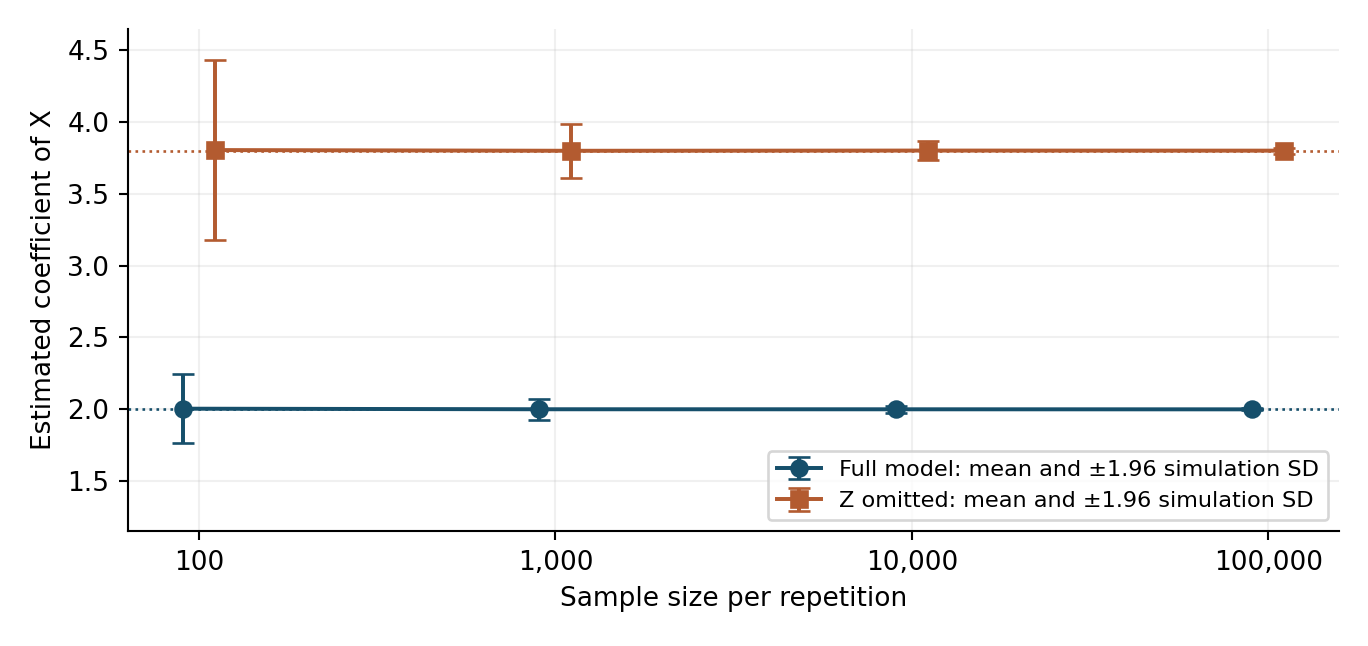

In [ ]:
rng = np.random.RandomState(123)
n = 1000
x = rng.normal(size=n)
z = .6 * x + rng.normal(size=n)
eps = rng.normal(size=n)
y = 1 + 2*x + 3*z + eps
full = sm.OLS(y, sm.add_constant(np.column_stack([x, z]))).fit()
omit = sm.OLS(y, sm.add_constant(x)).fit()
original_params = pd.DataFrame([
    {'Model': 'True parameters', 'Intercept': 1., 'X': 2., 'Z': 3.},
    {'Model': 'Full OLS', 'Intercept': full.params[0], 'X': full.params[1], 'Z': full.params[2]},
    {'Model': 'Z omitted', 'Intercept': omit.params[0], 'X': omit.params[1], 'Z': np.nan},
])
display(original_params)

# Continue the same RNG sequence as the source PDF's samplesize loop.
single = []
for n in [100, 1000, 10000, 100000]:
    x = rng.normal(size=n)
    z = .6*x + rng.normal(size=n)
    eps = rng.normal(size=n)
    y = 1 + 2*x + 3*z + eps
    fm = sm.OLS(y, sm.add_constant(np.column_stack([x, z]))).fit()
    om = sm.OLS(y, sm.add_constant(x)).fit()
    single.append({'n': n, 'full_b': fm.params[1], 'omitted_b': om.params[1]})
single_table = pd.DataFrame(single)
display(single_table)

# Monte Carlo extension. Draw x, independent v, and eps in that order in each
# repetition. Vectorized centered cross-products are exact two predictor OLS.
mc_rng = np.random.default_rng(20260923)
mc = []
repetitions = 1000
for n in [100, 1000, 10000, 100000]:
    slopes_full, slopes_omit = [], []
    for start in range(0, repetitions, 10):
        draws = mc_rng.normal(size=(min(10, repetitions-start), 3, n))
        x = draws[:, 0, :]
        z = .6*x + draws[:, 1, :]
        y = 1 + 2*x + 3*z + draws[:, 2, :]
        xc = x-x.mean(axis=1, keepdims=True)
        zc = z-z.mean(axis=1, keepdims=True)
        yc = y-y.mean(axis=1, keepdims=True)
        sxx=(xc*xc).sum(axis=1); szz=(zc*zc).sum(axis=1)
        sxz=(xc*zc).sum(axis=1); sxy=(xc*yc).sum(axis=1); szy=(zc*yc).sum(axis=1)
        bf=(sxy*szz-szy*sxz)/(sxx*szz-sxz*sxz)
        bo=sxy/sxx
        if start == 0:
            check = sm.OLS(y[0],sm.add_constant(np.column_stack([x[0],z[0]]))).fit()
            assert np.isclose(bf[0], check.params[1], atol=1e-10)
        slopes_full.extend(bf); slopes_omit.extend(bo)
    bf=np.array(slopes_full); bo=np.array(slopes_omit)
    mc.append({'n':n,'repetitions':repetitions,'full_mean':bf.mean(),'full_sd':bf.std(ddof=1),
               'omitted_mean':bo.mean(),'omitted_sd':bo.std(ddof=1),
               'full_rmse':np.sqrt(np.mean((bf-2)**2)), 'omitted_rmse':np.sqrt(np.mean((bo-2)**2))})
mc_table = pd.DataFrame(mc)
display(mc_table)
fig,ax=plt.subplots(figsize=(7.2,3.4))
xx=np.arange(len(mc))
ax.errorbar(xx-.045,mc_table.full_mean,yerr=1.96*mc_table.full_sd,fmt='o-',capsize=4,
            label='Full model: mean and ±1.96 simulation SD',color='#164F6B')
ax.errorbar(xx+.045,mc_table.omitted_mean,yerr=1.96*mc_table.omitted_sd,fmt='s-',capsize=4,
            label='Z omitted: mean and ±1.96 simulation SD',color='#B35B30')
ax.axhline(2,color='#164F6B',linestyle=':',linewidth=1)
ax.axhline(3.8,color='#B35B30',linestyle=':',linewidth=1)
ax.set_xticks(xx,[f'{int(n):,}' for n in mc_table.n]);ax.set_xlabel('Sample size per repetition')
ax.set_ylabel('Estimated coefficient of X');ax.set_ylim(1.15,4.65)
ax.legend(loc='lower right',fontsize=8.5)
fig.tight_layout();fig.savefig(FIG/'p1_simulation.png');plt.close(fig)
display(Image(filename=str(FIG/'p1_simulation.png')))
results['p1']={'original':original_params.where(pd.notnull(original_params),None).to_dict('records'),
               'single':single,'mc':mc,'seed_original':123,'seed_mc':20260923}

## Problem 2b: reproduce the original outlier experiment

Added observation diagnostics: {'leverage': 0.7116370487950383, 'cooks_distance': 56.375270142348}


,Sample,n,Intercept,Slope,RMSE_on_original_50
0,Clean,50,1.041022,2.103076,0.860278
1,"Add (10, -20)",51,0.143553,-0.801161,2.829248


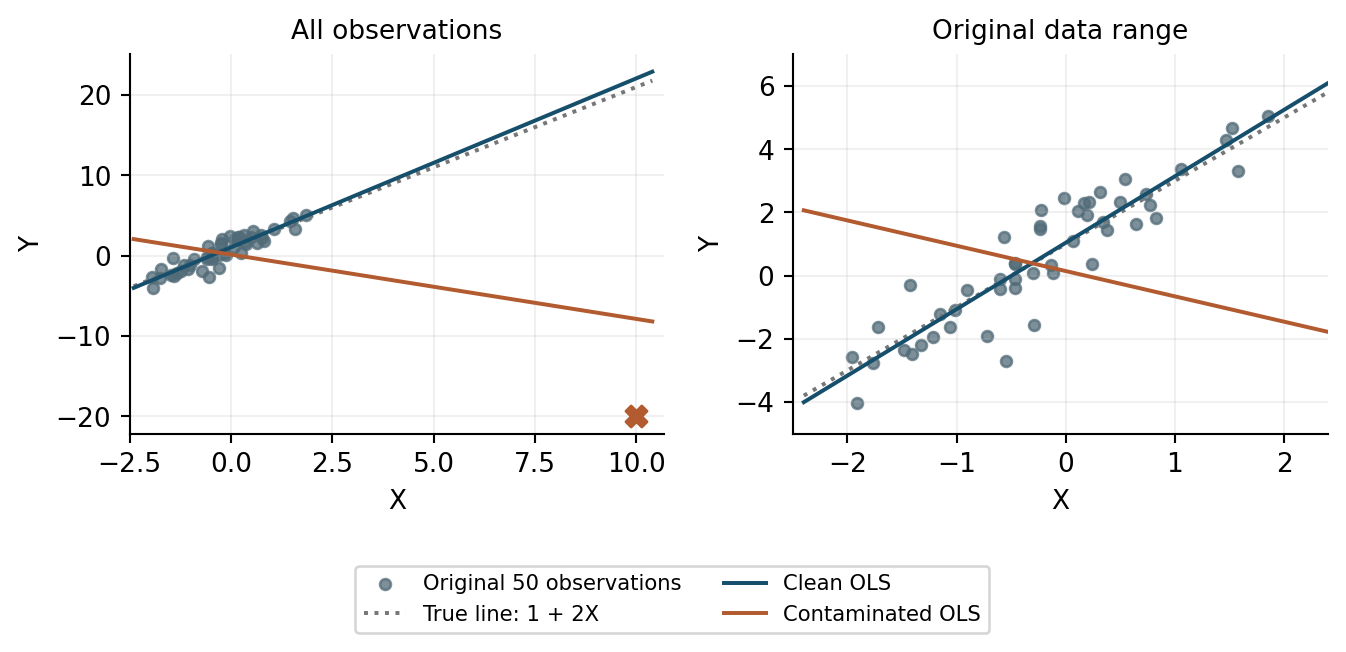

In [4]:
rng=np.random.RandomState(42)
x=rng.normal(size=50); e=rng.normal(size=50);y=1+2*x+e
xo=np.append(x,10.);yo=np.append(y,-20.)
clean=sm.OLS(y,sm.add_constant(x)).fit()
contam=sm.OLS(yo,sm.add_constant(xo)).fit()
outlier_table=pd.DataFrame([
    {'Sample':'Clean','n':50,'Intercept':clean.params[0],'Slope':clean.params[1],
     'RMSE_on_original_50':np.sqrt(np.mean(clean.resid**2))},
    {'Sample':'Add (10, -20)','n':51,'Intercept':contam.params[0],'Slope':contam.params[1],
     'RMSE_on_original_50':np.sqrt(np.mean((y-contam.predict(sm.add_constant(x)))**2))}
])
influence=contam.get_influence()
outlier_details={'leverage':float(influence.hat_matrix_diag[-1]),
                  'cooks_distance':float(influence.cooks_distance[0][-1])}
display(outlier_table)
print('Added observation diagnostics:',outlier_details)
fig,axes=plt.subplots(1,2,figsize=(7.2,3.35))
for ax in axes:
    ax.scatter(x,y,s=17,alpha=.75,color='#516B78',label='Original 50 observations')
    grid=np.linspace(-2.4,10.4,250)
    ax.plot(grid,1+2*grid,color='#777777',linestyle=':',label='True line: 1 + 2X')
    ax.plot(grid,clean.params[0]+clean.params[1]*grid,color='#164F6B',label='Clean OLS')
    ax.plot(grid,contam.params[0]+contam.params[1]*grid,color='#B35B30',label='Contaminated OLS')
    ax.set_xlabel('X');ax.set_ylabel('Y')
axes[0].scatter([10],[-20],color='#B35B30',marker='X',s=65,zorder=6)
axes[0].set_title('All observations',fontsize=10);axes[0].set_xlim(-2.5,10.7)
axes[1].set_title('Original data range',fontsize=10);axes[1].set_xlim(-2.5,2.4);axes[1].set_ylim(-5,7)
handles,labels=axes[1].get_legend_handles_labels()
fig.legend(handles,labels,loc='lower center',ncol=2,fontsize=8,bbox_to_anchor=(.5,-.03))
fig.tight_layout(rect=[0,.12,1,1]);fig.savefig(FIG/'p2_outlier.png',bbox_inches='tight');plt.close(fig)
display(Image(filename=str(FIG/'p2_outlier.png')))
results['p2']={'table':outlier_table.to_dict('records'),**outlier_details}

## Problem 3a: systematic model selection on the assigned CSV

In [ ]:
predictors=['X1','X2','X3','X4','X5']
def fit_model(names):
    return sm.OLS(model_data.Y,sm.add_constant(model_data[list(names)],has_constant='add')).fit()
def model_row(names,model):
    return {'predictors':list(names),'terms':','.join(names) if names else 'Intercept only',
            'k':int(model.df_model+1),'aic':model.aic,'bic':model.bic,
            'adj_r2':model.rsquared_adj,'r2':model.rsquared,'sse':model.ssr}

# Approach 1: forward selection by AIC, starting with the intercept only model.
included=[]
forward=[{'step':'Start',**model_row(included,fit_model(included))}]
while len(included)<len(predictors):
    candidates=[(fit_model(included+[v]).aic,v) for v in predictors if v not in included]
    best_aic,best_var=min(candidates)
    if best_aic >= forward[-1]['aic']-1e-12: break
    included.append(best_var)
    forward.append({'step':f'Add {best_var}',**model_row(included,fit_model(included))})
forward_selected=list(included)

# Approach 2: backward elimination by BIC, starting with all five predictors.
included=list(predictors)
backward=[{'step':'Start',**model_row(included,fit_model(included))}]
while included:
    candidates=[(fit_model([v for v in included if v!=drop]).bic,drop) for drop in included]
    best_bic,drop=min(candidates)
    if best_bic >= backward[-1]['bic']-1e-12: break
    included.remove(drop)
    backward.append({'step':f'Drop {drop}',**model_row(included,fit_model(included))})
backward_selected=list(included)

# Global check: evaluate all 2^5=32 subsets using AIC, BIC, and adjusted R².
all_models=[]
for p in range(6):
    for names in combinations(predictors,p):
        all_models.append(model_row(names,fit_model(names)))
all_table=pd.DataFrame(all_models)
winners={
    'AIC':all_table.loc[all_table.aic.idxmin(),'predictors'],
    'BIC':all_table.loc[all_table.bic.idxmin(),'predictors'],
    'Adjusted R2':all_table.loc[all_table.adj_r2.idxmax(),'predictors']}
assert all(set(v)==set(backward_selected) for v in winners.values())
assert set(forward_selected)==set(backward_selected)
selected=fit_model(backward_selected)
ci=selected.conf_int()
coef=pd.DataFrame({'term':selected.params.index,'estimate':selected.params.values,
                   'std_error':selected.bse.values,'t':selected.tvalues.values,'p':selected.pvalues.values,
                   'ci_low':ci[0].values,'ci_high':ci[1].values})
display(pd.DataFrame(forward).drop(columns='predictors'))
display(pd.DataFrame(backward).drop(columns='predictors'))
display(all_table.sort_values('bic').drop(columns='predictors'))
display(coef)
print('Winners:',winners)
print('Selected regression:',selected.summary())
results['p3']={'forward':forward,'backward':backward,'all':all_models,'winners':winners,
               'selected':model_row(backward_selected,selected),'coef':coef.to_dict('records'),
               'residual_se':float(np.sqrt(selected.mse_resid)),
               'f_test':float(selected.fvalue),'f_p':float(selected.f_pvalue)}

Winners: {'AIC': ['X2', 'X3', 'X4', 'X5'], 'BIC': ['X2', 'X3', 'X4', 'X5'], 'Adjusted R2': ['X2', 'X3', 'X4', 'X5']}
Selected regression:                             OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     43.87
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           8.29e-21
Time:                        01:27:23   Log-Likelihood:                -125.31
No. Observations:                 100   AIC:                             260.6
Df Residuals:                      95   BIC:                             273.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      

,step,terms,k,aic,bic,adj_r2,r2,sse
0,Start,Intercept only,1,357.246131,359.851302,-0.000000,-0.000000,204.333698
1,Add X4,X4,2,325.028687,330.239028,0.282529,0.289776,145.122758
2,Add X3,"X4,X3",3,296.442510,304.258021,0.466143,0.476928,106.881230
3,Add X2,"X4,X3,X2",4,264.291054,274.711735,0.616639,0.628256,75.959755
4,Add X5,"X4,X3,X2,X5",5,260.616684,273.642535,0.633974,0.648763,71.769526


,step,terms,k,aic,bic,adj_r2,r2,sse
0,Start,"X1,X2,X3,X4,X5",6,262.592528,278.223549,0.630170,0.648848,71.752192
1,Drop X1,"X2,X3,X4,X5",5,260.616684,273.642535,0.633974,0.648763,71.769526


,terms,k,aic,bic,adj_r2,r2,sse
30,"X2,X3,X4,X5",5,260.616684,273.642535,0.633974,0.648763,71.769526
22,"X2,X3,X4",4,264.291054,274.711735,0.616639,0.628256,75.959755
31,"X1,X2,X3,X4,X5",6,262.592528,278.223549,0.630170,0.648848,71.752192
26,"X1,X2,X3,X4",5,266.191097,279.216948,0.612991,0.628628,75.883866
24,"X2,X4,X5",4,291.889597,302.310277,0.494796,0.510106,100.101942
13,"X3,X4",3,296.442510,304.258021,0.466143,0.476928,106.881230
25,"X3,X4,X5",4,294.842233,305.262914,0.479657,0.495425,103.101656
11,"X2,X4",3,299.002018,306.817529,0.452303,0.463367,109.652174
28,"X1,X2,X4,X5",5,293.801828,306.827678,0.489926,0.510535,100.014122
19,"X1,X3,X4",4,297.730057,308.150737,0.464411,0.480641,106.122457


,term,estimate,std_error,t,p,ci_low,ci_high
0,const,1.189339,0.089202,13.333088,0.000000,1.012251,1.366428
1,X2,-0.586083,0.091007,-6.440013,0.000000,-0.766754,-0.405412
2,X3,0.559157,0.091306,6.123977,0.000000,0.377891,0.740423
3,X4,0.710541,0.081932,8.672333,0.000000,0.547885,0.873196
4,X5,-0.196639,0.083495,-2.355107,0.020574,-0.362398,-0.030881


## Problem 4: transformations, inference, and turning point

In [6]:
df_resid=2000-6
crit=stats.t.ppf(.975,df_resid)
gender_ci=np.array([-.15-crit*.10,-.15+crit*.10])
results['p4']={'educ_exact_pct':float(100*np.expm1(.08)),
               'gender_exact_pct':float(100*np.expm1(-.15)),
               'gender_p':float(2*stats.t.sf(1.5,df_resid)),
               'gender_ci_log':gender_ci.tolist(),
               'gender_ci_pct':(100*np.expm1(gender_ci)).tolist(),
               'degree_exact_pct':float(100*np.expm1(.22)),
               'peak_age':.19/.004,'df':df_resid,
               'aic_overfit_probability':float(stats.chi2.sf(2,1))}
print(results['p4'])

{'educ_exact_pct': 8.328706767495856, 'gender_exact_pct': -13.92920235749422, 'gender_p': 0.1337727112796973, 'gender_ci_log': [-0.3461154399469396, 0.04611543994693959], 'gender_ci_pct': [-29.25691833833598, 4.719529214850478], 'degree_exact_pct': 24.607673058738083, 'peak_age': 47.5, 'df': 1994, 'aic_overfit_probability': 0.15729920705028105}


## Problem 5c: time-series plots and ADF tests

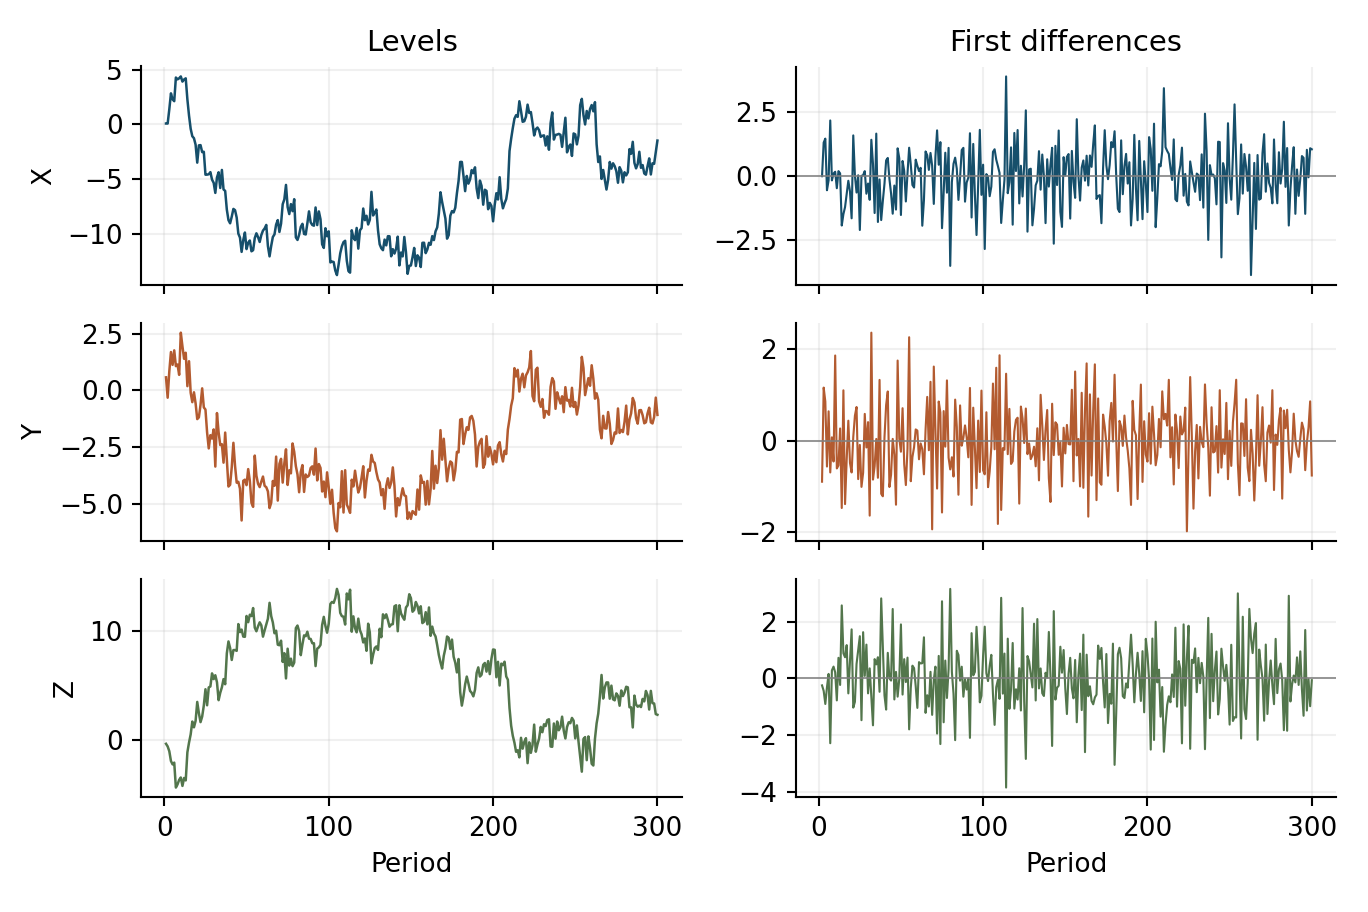

,series,transform,stat,p,lags,nobs,cv_5,reject_5
0,X,Level,-2.486236,0.118859,6,293,-2.871455,False
1,X,First difference,-10.339658,0.000000,3,295,-2.871388,True
2,Y,Level,-2.080296,0.252511,4,295,-2.871388,False
3,Y,First difference,-12.012434,0.000000,3,295,-2.871388,True
4,Z,Level,-1.966677,0.301372,1,298,-2.871288,False
5,Z,First difference,-22.510537,0.000000,0,298,-2.871288,True


In [7]:
fig,axes=plt.subplots(3,2,figsize=(7.2,4.8),sharex=True)
colors=['#164F6B','#B35B30','#53764C']
for i,(name,color) in enumerate(zip(levels,colors)):
    axes[i,0].plot(ts_data.Period,levels[name],color=color,lw=.95)
    axes[i,1].plot(ts_data.Period.iloc[1:],levels[name].diff().iloc[1:],color=color,lw=.8)
    axes[i,0].set_ylabel(name)
    axes[i,1].axhline(0,color='grey',lw=.6)
axes[0,0].set_title('Levels',fontsize=11);axes[0,1].set_title('First differences',fontsize=11)
axes[2,0].set_xlabel('Period');axes[2,1].set_xlabel('Period')
fig.tight_layout();fig.savefig(FIG/'p5_series.png');plt.close(fig)
display(Image(filename=str(FIG/'p5_series.png')))
adf_rows=[]
for name in levels:
    for transform,s in [('Level',levels[name]),('First difference',levels[name].diff().dropna())]:
        a=adfuller(s,maxlag=16,regression='c',autolag='AIC')
        adf_rows.append({'series':name,'transform':transform,'stat':float(a[0]),'p':float(a[1]),
                         'lags':int(a[2]),'nobs':int(a[3]),'cv_5':float(a[4]['5%']),
                         'reject_5':bool(a[0]<a[4]['5%'])})
adf_table=pd.DataFrame(adf_rows)
display(adf_table)

## Problem 5c: lag selection and Johansen rank tests

In [8]:
lag_order=select_order(levels,maxlags=10,deterministic='co')
lag_rows=[{'k_diff':i,'p_levels':i+1,**{key:float(lag_order.ics[key][i]) for key in ['aic','bic','hqic','fpe']}}
          for i in range(11)]
k=int(lag_order.bic)
print(lag_order.summary())
print('Selected difference lags:',dict(lag_order.selected_orders))

def johansen_checked(data,k_diff,det_order=0):
    # Some SciPy/NumPy combinations return real eigenvalues in complex dtype.
    # Check their imaginary parts explicitly before accepting the calculation.
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        test=coint_johansen(data,det_order=det_order,k_ar_diff=k_diff)
    assert np.max(np.abs(np.imag(test.eig)))<1e-10
    assert np.all((np.real(test.eig)>=0)&(np.real(test.eig)<1))
    for warning in captured:
        if warning.category.__name__!='ComplexWarning':
            warnings.warn(str(warning.message),warning.category)
    # Independently reconstruct both statistics from eigenvalues.
    eig=np.real(test.eig)
    t=len(data)-k_diff-1
    expected_max=-t*np.log1p(-eig)
    expected_trace=np.cumsum(expected_max[::-1])[::-1]
    assert np.allclose(test.lr1,expected_trace,rtol=1e-10)
    assert np.allclose(test.lr2,expected_max,rtol=1e-10)
    return test

joh=johansen_checked(levels,k)
def sequential_rank(stat,critical):
    for r in range(len(stat)):
        if stat[r]<critical[r]: return r
    return len(stat)

rank_trace=sequential_rank(joh.lr1,joh.cvt[:,1])
rank_max=sequential_rank(joh.lr2,joh.cvm[:,1])
assert rank_trace==rank_max
rank=rank_trace
joh_rows=[{'r':r,'eigenvalue':float(np.real(joh.eig[r])),
            'trace':float(joh.lr1[r]),'trace_cv5':float(joh.cvt[r,1]),
            'maxeig':float(joh.lr2[r]),'maxeig_cv5':float(joh.cvm[r,1]),
            'trace_reject':bool(joh.lr1[r]>joh.cvt[r,1]),
            'max_reject':bool(joh.lr2[r]>joh.cvm[r,1])} for r in range(3)]
display(pd.DataFrame(joh_rows))
print('Selected rank:',rank)
sensitivity=[]
for kd in [0,1]:
    j=johansen_checked(levels,kd)
    sensitivity.append({'k_diff':kd,'nobs':len(levels)-kd-1,
                        'last_stat':float(j.lr1[-1]),
                        'trace_rank_5':sequential_rank(j.lr1,j.cvt[:,1]),
                        'max_rank_5':sequential_rank(j.lr2,j.cvm[:,1]),
                        'trace_rank_1':sequential_rank(j.lr1,j.cvt[:,2]),
                        'max_rank_1':sequential_rank(j.lr2,j.cvm[:,2])})
display(pd.DataFrame(sensitivity))

 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -1.916*     -1.726*     0.1472*     -1.840*
1       -1.900      -1.595      0.1496      -1.778
2       -1.857      -1.439      0.1561      -1.690
3       -1.822      -1.289      0.1617      -1.609
4       -1.800      -1.153      0.1654      -1.541
5       -1.782      -1.020      0.1685      -1.477
6       -1.792     -0.9166      0.1668      -1.441
7       -1.736     -0.7461      0.1765      -1.339
8       -1.679     -0.5752      0.1870      -1.237
9       -1.629     -0.4115      0.1966      -1.141
10      -1.601     -0.2693      0.2023      -1.068
--------------------------------------------------
Selected difference lags: {'aic': np.int64(0), 'bic': np.int64(0), 'hqic': np.int64(0), 'fpe': np.int64(0)}
Selected rank: 2


,r,eigenvalue,trace,trace_cv5,maxeig,maxeig_cv5,trace_reject,max_reject
0,0,0.540431,435.996086,29.796100,232.462304,21.131400,True,True
1,1,0.487767,203.533782,15.494300,200.023473,14.263900,True,True
2,2,0.011672,3.510309,3.841500,3.510309,3.841500,False,False


,k_diff,nobs,last_stat,trace_rank_5,max_rank_5,trace_rank_1,max_rank_1
0,0,299,3.510309,2,2,2,2
1,1,298,3.925153,3,3,2,2


## Problem 5c: maximum-likelihood VECM, complete estimates, diagnostics

Det. terms outside the coint. relation & lagged endog. parameters for equation X
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0052      0.067     -0.077      0.938      -0.137       0.126
Det. terms outside the coint. relation & lagged endog. parameters for equation Y
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1274      0.038      3.346      0.001       0.053       0.202
Det. terms outside the coint. relation & lagged endog. parameters for equation Z
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0952      0.067      1.411      0.158      -0.037       0.227
                 Loading coefficients (alpha) 

,equation,term,estimate,se,p
0,X,EC1,-0.470991,0.097544,0.000001
1,X,EC2,0.261096,0.124253,0.035612
2,Y,EC1,0.148711,0.055351,0.007216
3,Y,EC2,-0.933446,0.070506,0.000000
4,Z,EC1,-0.532503,0.098093,0.000000
5,Z,EC2,-0.257145,0.124952,0.039596


,variable,relation,estimate,se
0,X,EC1,1.000000,0.000000
1,X,EC2,0.000000,0.000000
2,Y,EC1,0.000000,0.000000
3,Y,EC2,1.000000,0.000000
4,Z,EC1,1.008446,0.008630
5,Z,EC2,0.415704,0.006387


,equation,estimate,se,p
0,X,-0.005193,0.067096,0.938308
1,Y,0.127408,0.038073,0.000819
2,Z,0.095195,0.067474,0.158291


,X,Y,Z
X,1.236466,0.389664,-1.012976
Y,0.389664,0.398132,-0.399583
Z,-1.012976,-0.399583,1.250433


,lags,stat,df,p
0,10,78.321825,84,0.654169
1,20,188.576927,174,0.212988


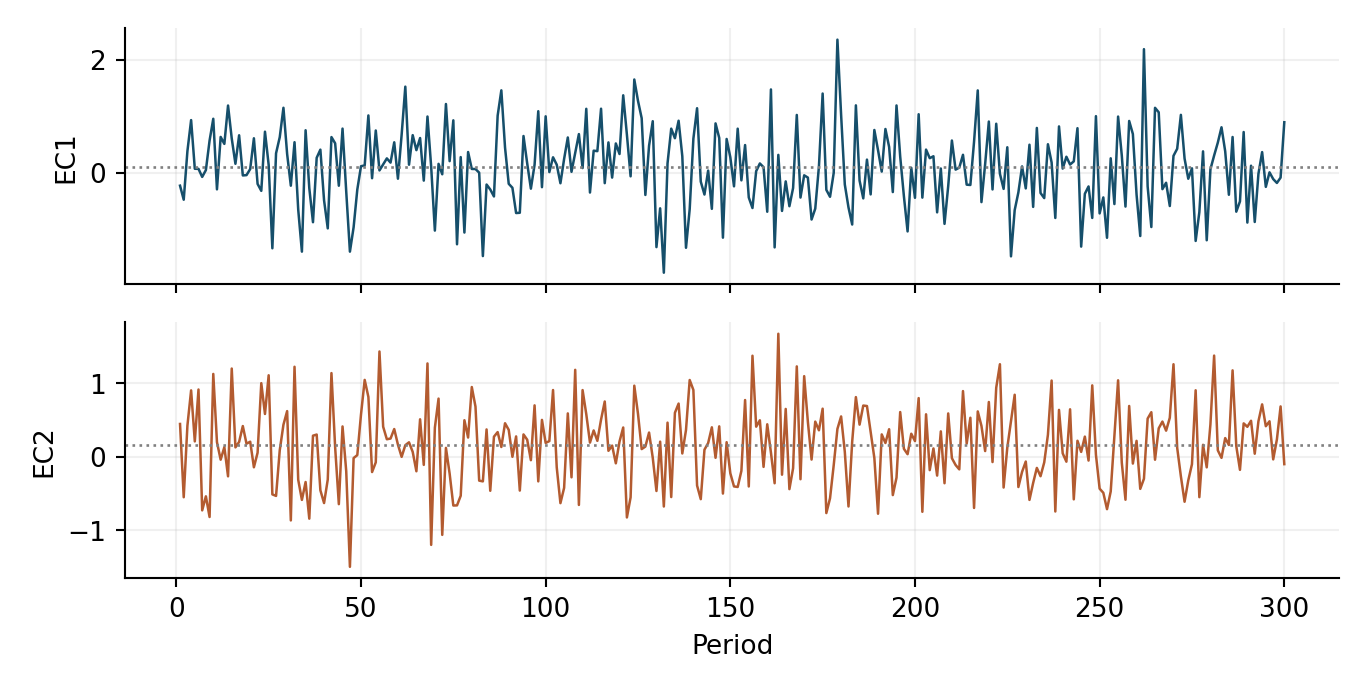

In [9]:
vecm=VECM(levels,k_ar_diff=k,coint_rank=rank,deterministic='co').fit()
print(vecm.summary())
alpha_rows=[]
beta_rows=[]
const_rows=[]
for i,name in enumerate(levels):
    for j in range(rank):
        alpha_rows.append({'equation':name,'term':f'EC{j+1}', 'estimate':float(vecm.alpha[i,j]),
                            'se':float(vecm.stderr_alpha[i,j]),'p':float(vecm.pvalues_alpha[i,j])})
        beta_rows.append({'variable':name,'relation':f'EC{j+1}','estimate':float(vecm.beta[i,j]),
                          'se':float(vecm.stderr_beta[i,j])})
    const_rows.append({'equation':name,'estimate':float(vecm.const[i,0]),
                       'se':float(vecm.stderr_det_coef[i,0]),'p':float(vecm.pvalues_det_coef[i,0])})
pi=vecm.alpha@vecm.beta.T
residuals=vecm.resid
diagnostics=[]
for horizon in [10,20]:
    test=vecm.test_whiteness(nlags=horizon,adjusted=True)
    diagnostics.append({'lags':horizon,'stat':float(test.test_statistic),'df':int(test.df),'p':float(test.pvalue)})
display(pd.DataFrame(alpha_rows));display(pd.DataFrame(beta_rows));display(pd.DataFrame(const_rows))
display(pd.DataFrame(vecm.sigma_u,index=levels.columns,columns=levels.columns))
display(pd.DataFrame(diagnostics))
ecs=levels.to_numpy()@vecm.beta
fig,axes=plt.subplots(2,1,figsize=(7.2,3.65),sharex=True)
for j,ax in enumerate(axes):
    ax.plot(ts_data.Period,ecs[:,j],color=colors[j],lw=.95)
    ax.axhline(ecs[:,j].mean(),color='grey',linestyle=':',lw=1)
    ax.set_ylabel(f'EC{j+1}')
axes[1].set_xlabel('Period')
fig.tight_layout();fig.savefig(FIG/'p5_equilibria.png');plt.close(fig)
display(Image(filename=str(FIG/'p5_equilibria.png')))
results['p5']={'adf':adf_rows,'lags':lag_rows,'selected_lags':{key:int(val) for key,val in lag_order.selected_orders.items()},
               'k_diff':k,'rank':rank,'johansen':joh_rows,'sensitivity':sensitivity,
               'alpha':vecm.alpha.tolist(),'beta':vecm.beta.tolist(),'constant':vecm.const[:,0].tolist(),
               'alpha_rows':alpha_rows,'beta_rows':beta_rows,'const_rows':const_rows,
               'sigma':vecm.sigma_u.tolist(),'pi':pi.tolist(),'nobs':int(vecm.nobs),
               'llf':float(vecm.llf),'diagnostics':diagnostics,
               'beta_y_z_ci':[float(vecm.beta[2,1]-1.96*vecm.stderr_beta[2,1]),
                              float(vecm.beta[2,1]+1.96*vecm.stderr_beta[2,1])]}

## Problem 6 and numerical validation

In [ ]:
rho1=.6/(1-.2);rho2=.6*rho1+.2
ar_roots=np.roots([-.2,-.6,1.])
assert np.all(np.abs(ar_roots)>1)
results['p6']={'rho1':rho1,'rho2':rho2,'ar_roots':ar_roots.tolist()}
print('AR(2) roots:',ar_roots,'; rho(1)=',rho1,'; rho(2)=',rho2)
# Validate selected regression coefficients by an independent least squares solve.
design=np.column_stack([np.ones(len(model_data)),model_data[backward_selected]])
assert np.allclose(np.linalg.lstsq(design,model_data.Y,rcond=None)[0],selected.params)
assert rank==2 and k==0
assert len(vecm.resid)==299 and vecm.gamma.shape==(3,0)
assert np.allclose(vecm.fittedvalues+vecm.resid,levels.to_numpy()[1:])
# Verify that reconstructed VECM equations match the fitted differences
predicted_delta=(levels.to_numpy()[:-1]@pi.T)+vecm.const[:,0]
assert np.allclose(predicted_delta,vecm.fittedvalues-levels.to_numpy()[:-1])
with (OUT/'results.json').open('w') as f:
    json.dump(results,f,indent=2,allow_nan=True)
print('All numerical reconciliation checks passed.')

AR(2) roots: [-4.1925824  1.1925824] ; rho(1)= 0.7499999999999999 ; rho(2)= 0.6499999999999999
All numerical reconciliation checks passed.
